In [1]:
import h5py
import numpy as np
import os
import matplotlib.pyplot as plt
import os
import tensorflow as tf

2026-03-02 10:01:53.363679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772474513.380037 1114593 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772474513.385242 1114593 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772474513.399547 1114593 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772474513.399561 1114593 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772474513.399563 1114593 computation_placer.cc:177] computation placer alr

In [2]:
print("here")

here


In [9]:
# minorized reference
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    ref_d = file['density'][:]
#print(ref_d)
print(ref_d.shape)




(64, 64, 64)


In [11]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [5]:
data = np.load("/pscratch/sd/k/kberard/SCGSR/EDDA/Diamond/Data_Gen/DFT_Blobs_Fixed/DFT_dat_lev__FT2435433000000_samples_Residual_Perturbed.npz")


In [6]:
print(data['x_train'].shape)

(1000, 64, 64, 64)


In [7]:
x_train = data['x_train']
x_val   = data['x_val']
y_train = data['y_train']
y_val   = data['y_val']
n_samples = data["total_samples"]

x_train = x_train[..., np.newaxis]
x_val   = x_val[..., np.newaxis]

y_train = y_train[..., np.newaxis]
y_val   = y_val[..., np.newaxis]
data = 0


In [8]:
dft_path ='/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]
# 1. Get the residual map (what the network sees)
residual_map = x_train[0,:,:,:,0]
print(f"Residual Sum: {np.sum(residual_map):.2f} (Expected: close to 0, not 50)")

# 2. Inverse Transform to get Real Density
# Formula: Density = (Residual * sqrt(DFT)) + DFT
epsilon = 1e-9
dsqrt = np.sqrt(np.abs(dft_d) + epsilon)
restored_density = (residual_map * dsqrt) + dft_d

# 3. Check the Sum
total_electrons = np.sum(restored_density)
print(f"Total Electrons: {total_electrons:.4f} (Expected: ~8.0)")

Residual Sum: -0.26 (Expected: close to 0, not 50)
Total Electrons: 7.9977 (Expected: ~8.0)


In [25]:
import os
import glob
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks

# ==========================================
# 1. TRANSFORMATION FUNCTIONS (Decoupled from DFT)
# ==========================================

def transform(density, density_ref, transform_type, eps=1e-8):
    if transform_type == 'value':
        return density
    elif transform_type == 'sqrt':
        # Variance stabilization: No DFT reference needed
        return np.sqrt(np.abs(density))
    elif transform_type == 'log':
        return np.log(np.abs(density) + eps)
    elif transform_type == 'residual_noise':
        # Keeping this for legacy compatibility, but we won't use it for training
        dval = density_ref
        dsqrt = np.sqrt(np.abs(density_ref) + eps) 
        return (density - dval) / dsqrt
    else:
        raise RuntimeError('bad transform type')

def inverse_transform(density_trans, density_ref, transform_type, eps=1e-8):
    if transform_type == 'value':
        return density_trans
    elif transform_type == 'sqrt':
        # Reversing the variance stabilization
        return density_trans**2
    elif transform_type == 'log':
        return np.exp(density_trans) - eps 
    elif transform_type == 'residual_noise':
        dval = density_ref
        dsqrt = np.sqrt(np.abs(density_ref) + eps)
        return dval + dsqrt * density_trans
    else:
        raise RuntimeError('bad transform type')

# ==========================================
# 2. DATA LOADING & PARSING
# ==========================================

data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/'
file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")

def load_h5_density(fpath):
    with h5py.File(fpath, 'r') as f:
        return np.array(f['density'])

all_files = glob.glob(file_pattern)
file_info = []

for f in all_files:
    basename = os.path.basename(f)
    sample_str = basename.replace("density_tot_vmc_mean_", "").replace(".h5", "")
    try:
        file_info.append((int(sample_str), f))
    except ValueError:
        pass

# Sort by sample count (lowest to highest)
file_info.sort(key=lambda x: x[0])

# Define our thresholds
max_input_samples = 50000000  
target_sample_min = 100000000 

low_sample_files = [info for info in file_info if info[0] <= max_input_samples]
target_candidates = [info for info in file_info if info[0] >= target_sample_min]

if not target_candidates:
    raise ValueError("No files found above the target_sample_min threshold!")

target_file = target_candidates[0][1]

# ==========================================
# 3. BUILD THE TRANSFORMED DATASET
# ==========================================

print(f"Loading Target Density (Pseudo-Ground Truth): {os.path.basename(target_file)}")
clean_density = load_h5_density(target_file)

# Transform target using 'sqrt' (No DFT needed)
clean_trans = transform(clean_density, None, 'sqrt')

x_train_list = []
y_train_list = []

print(f"Processing {len(low_sample_files)} low-sample files for training...")
for samples, filepath in low_sample_files:
    noisy_input = load_h5_density(filepath)
    
    # Transform input using 'sqrt'
    input_trans = transform(noisy_input, None, 'sqrt')
    
    # Target is the RESIDUAL in the sqrt space
    target_residual = clean_trans - input_trans
    
    # Add channel dimension (X, Y, Z, 1) for the 3D CNN
    x_train_list.append(np.expand_dims(input_trans, axis=-1))
    y_train_list.append(np.expand_dims(target_residual, axis=-1))

x_train = np.array(x_train_list)
y_train = np.array(y_train_list)

print(f"Dataset built! x_train shape: {x_train.shape}")

# ==========================================
# 4. MODEL LOADING & FINE-TUNING
# ==========================================

print("Loading pre-trained model...")
model = tf.keras.models.load_model("residual_denoiser_40M_Blob_Fixed_trans.keras")

# CRITICAL FIX: Unfreeze the entire network so it forgets the DFT bias
print("Unfreezing all layers to break DFT collapse...")
for layer in model.layers:
    layer.trainable = True

# Compile with a lower learning rate since the whole network is updating
# 1. Bump the learning rate slightly to give it a stronger push
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4) 

# 2. Switch loss from 'mse' to 'mae' (Mean Absolute Error)
model.compile(optimizer=optimizer, loss='mae')

print("Starting fine-tuning with MAE...")
history = model.fit(
    x_train, y_train, # Ensure you are still using the 'sqrt' transformed data
    validation_split=0.1, 
    batch_size=4,         
    epochs=50,
    callbacks=[
        # Monitor val_loss, and give it a bit more patience
        callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6)
    ]
)
model.save("residual_denoiser_VMC_finetuned_sqrt.keras")
print("Fine-tuning complete. Saved to residual_denoiser_VMC_finetuned_sqrt.keras")




Loading Target Density (Pseudo-Ground Truth): density_tot_vmc_mean_0110100480.h5
Processing 22 low-sample files for training...
Dataset built! x_train shape: (22, 64, 64, 64, 1)
Loading pre-trained model...
Unfreezing all layers to break DFT collapse...
Starting fine-tuning with MAE...
Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - loss: 9.8399e-04 - val_loss: 8.5411e-05 - learning_rate: 1.0000e-04
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 7.0231e-04 - val_loss: 9.0249e-05 - learning_rate: 1.0000e-04
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 7.7429e-04 - val_loss: 9.6915e-05 - learning_rate: 1.0000e-04
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 9.1635e-04 - val_loss: 8.2252e-05 - learning_rate: 1.0000e-04
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 8.3148e-04 - val_loss: 9.2252e-05 - learning_rate: 1.0000e-04
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0012 - val_loss: 8.2010e-05 - learning_rate: 1.0000e-04
Epoc

In [18]:
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_vmc_mean_0000655360.h5', 'r') as file:
    #print("Keys: %s" % file.keys())
    test_d = file['density'][:]

In [19]:
#Transform density
def transform(density,density_ref,transform_type):
    dens = density
    dref  = density_ref
    ttype = transform_type
    if ttype=='value':
        dtrans = density
    elif ttype=='sqrt':
        dtrans = np.sqrt(np.abs(density))
    elif ttype=='log':
        dtrans  = np.log(np.abs(density))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        dtrans = (dens-dval)/dsqrt
    else:
        raise RuntimeError('bad transform type')
    return dtrans


def inverse_transform(density_trans,density_ref,transform_type):
    dref   = density_ref
    ttype  = transform_type
    dtrans = density_trans
    if ttype=='value':
        density = dtrans
    elif ttype=='sqrt':
        density = dtrans**2
    elif ttype=='log':
        density = np.log(np.abs(dtrans))
    elif ttype=='residual_noise':
        dval  = dref
        dsqrt = np.sqrt(np.abs(dref))
        density = dval + dsqrt*dtrans
    else:
        raise RuntimeError('bad transform type')
    return density


In [7]:
import os
import glob
import h5py
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re
dft_path ='/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5'
with h5py.File(dft_path, 'r') as file:
    dft_d = file['density'][:]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 536ms/step


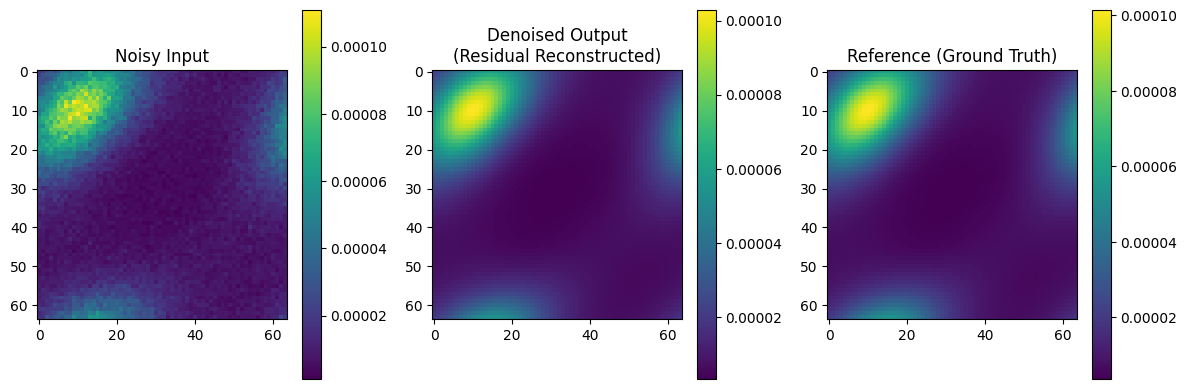

JSD between noisy and Ref: 0.0023806291485216945
JSD between denoised and Ref: 0.00010708899353664055
JSD between denoised and DFT: 1.8347576053443272e-06
JSD between noise and DFT: 0.002481114831835906
JSD between Ref and DFT: 0.00012671965457473964


In [26]:
import numpy as np
import matplotlib.pyplot as plt
model = tf.keras.models.load_model('residual_denoiser_VMC_finetuned_sqrt.keras')
# -----------------------------------------------------------
# 1. PREPARE DATA FOR MODEL
# -----------------------------------------------------------
# Reshape arrays to (1, H, W, D, 1) for the model
# We need 'dft_d' because the residual transform relies on it.
input_reshaped = test_d[np.newaxis, ..., np.newaxis]
dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]

# -----------------------------------------------------------
# 2. TRANSFORM INPUT (Forward Pass)
# -----------------------------------------------------------
# Convert raw noisy density -> "How far is this from DFT?"
# Uses the 'transform' function we defined earlier
input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')

# -----------------------------------------------------------
# 3. PREDICT
# -----------------------------------------------------------
# The model predicts the "Corrected Residual"
pred_residual = model.predict(input_residual)

# -----------------------------------------------------------
# 4. INVERSE TRANSFORM (Recover Density)
# -----------------------------------------------------------
# Convert "Corrected Residual" back to "Physical Density"
# Logic: Density = DFT + (Residual * sqrt(DFT))
denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')

# Squeeze back to 3D shape (116, 116, 72)
denoised = denoised_raw[0, ..., 0]

# Safety: Density cannot be negative (physics constraint)
denoised = np.maximum(denoised, 0.0)

# -----------------------------------------------------------
# 5. VISUALIZATION & METRICS (Your snippet)
# -----------------------------------------------------------
noisy_input = test_d
true_clean = ref_d

# Dynamic z-slice (don't hardcode 64 if depth is 72)
z_mid = noisy_input.shape[2] // 2

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(noisy_input[:, :, z_mid], cmap='viridis')
plt.title("Noisy Input")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(denoised[:, :, z_mid], cmap='viridis')
plt.title("Denoised Output\n(Residual Reconstructed)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(true_clean[:, :, z_mid], cmap='viridis')
plt.title("Reference (Ground Truth)")
plt.colorbar()

plt.tight_layout()
plt.show()

# Metric Calculation
# Ensure JSD handles small epsilons
print("JSD between noisy and Ref:", D_JS(test_d, ref_d, tol=1e-16))
print("JSD between denoised and Ref:", D_JS(denoised, ref_d, tol=1e-16))
print("JSD between denoised and DFT:", D_JS(denoised, dft_d, tol=1e-16))
print("JSD between noise and DFT:", D_JS(test_d, dft_d, tol=1e-16))
print("JSD between Ref and DFT:", D_JS(ref_d, dft_d, tol=1e-16))

In [14]:
print("here")

here


In [27]:
# --- Setup Directory Looping ---
model = tf.keras.models.load_model('residual_denoiser_VMC_finetuned_sqrt.keras')
data_dir = '/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/'
file_pattern = os.path.join(data_dir, "density_tot_vmc_mean_*.h5")
files = glob.glob(file_pattern)

results = []

# --- Processing Loop ---
for fpath in files:
    # Extract number of samples from filename using regex
    match = re.search(r'mean_(\d+)\.h5', os.path.basename(fpath))
    if not match: continue
    sample_count = int(match.group(1))
    
    with h5py.File(fpath, 'r') as f:
        test_d = np.array(f['density'])
    
    # 1. Transform & Predict
    input_reshaped = test_d[np.newaxis, ..., np.newaxis]
    dft_reshaped   = dft_d[np.newaxis, ..., np.newaxis]
    input_residual = transform(input_reshaped, dft_reshaped, 'residual_noise')
    
    pred_residual = model.predict(input_residual, verbose=0)
    
    # 2. Inverse Transform
    denoised_raw = inverse_transform(pred_residual, dft_reshaped, 'residual_noise')
    denoised = np.maximum(denoised_raw[0, ..., 0], 0.0)

    # 3. Store Metrics
    jsd_noisy = D_JS(test_d, ref_d)
    jsd_denoised = D_JS(denoised, ref_d)
    
    results.append((sample_count, jsd_noisy, jsd_denoised))

# --- Sorting & Plotting ---
# Sort results by sample count (x-axis)
results.sort(key=lambda x: x[0])
samples, noisy_jsds, denoised_jsds = zip(*results)



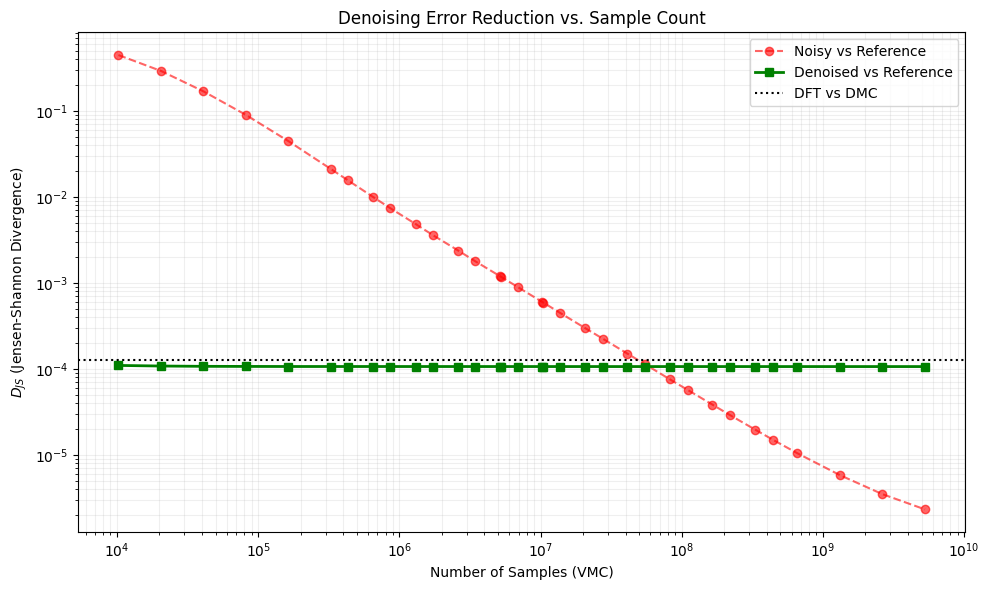

In [28]:
DFT_vs_DMC = D_JS(ref_d,dft_d)
plt.figure(figsize=(10, 6))
plt.plot(samples, noisy_jsds, 'r--o', label='Noisy vs Reference', alpha=0.6)
plt.plot(samples, denoised_jsds, 'g-s', label='Denoised vs Reference', linewidth=2)

plt.xscale('log') # Sample counts usually span orders of magnitude
plt.yscale('log') # JSD values often drop significantly
plt.axhline(DFT_vs_DMC, color="black", linestyle=":", label="DFT vs DMC")
plt.xlabel('Number of Samples (VMC)')
plt.ylabel('$D_{JS}$ (Jensen-Shannon Divergence)')
plt.title('Denoising Error Reduction vs. Sample Count')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# Create a DataFrame with your data
data = {
    'Samples': samples,
    'Noisy_JSD': noisy_jsds,
    'Denoised_JSD': denoised_jsds
}
df = pd.DataFrame(data)

# Save to CSV
df.to_csv('diamond_jsd_data.csv', index=False)
print("Data saved to diamond_jsd_data.csv")


Data saved to diamond_jsd_data.csv
